# SHAP Analysis — LightGBM F1 Race Position Model

Explains the predictions of the default-parameter `LGBMRegressor` from `lightgbm.ipynb` using **SHAP (SHapley Additive exPlanations)**. Where the feature-importance table in that notebook only ranks features by split count, SHAP attributes each individual prediction to its input features in units of the target (finishing position), with a sign — so we can see not just *which* features matter, but *how* and *in which direction* they push a given prediction away from the model's average output.

All SHAP values are computed with `shap.TreeExplainer` (exact, fast for tree ensembles) on the held-out **2025 test set** — the same set `lightgbm.ipynb` uses for final evaluation — so the explanations describe genuine out-of-sample behaviour rather than in-sample fit.

**Note on feature scale:** `FINAL_FEATURES` are the *post-feature-engineering* columns — the 8 continuous features are standardised (zero mean, unit variance) and the 2 categorical features (`TeamName`, `Meeting.Circuit.ShortName`) are label-encoded integers. Dependence plots below show these transformed values, not raw grid positions or team names; axis values are z-scores unless noted otherwise.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from lightgbm import LGBMRegressor

sys.path.insert(0, str(Path.cwd().parent))
from pipeline.feature_engineering.feature_engineering import FINAL_FEATURES, TARGET

shap.initjs()

c:\Users\SwaroopPC\anaconda3\envs\f1-pit-wall\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Data and Fit the Model

Same setup as `lightgbm.ipynb` Sections 2–3 and 8: load the pre-split Parquet files, restrict to `FINAL_FEATURES`, and fit `LGBMRegressor` with default hyperparameters (`random_state=42`, `verbose=-1`) on the full 2019–2024 training set.

In [2]:
train = pd.read_parquet('../data/train.parquet')
test = pd.read_parquet('../data/test.parquet')

train_X = train[FINAL_FEATURES]
train_Y = train[TARGET]
test_X = test[FINAL_FEATURES]
test_Y = test[TARGET]

model = LGBMRegressor(random_state=42, verbose=-1)
model.fit(train_X, train_Y)

test_preds = model.predict(test_X)
print(f"Fitted on {train_X.shape[0]} rows; explaining {test_X.shape[0]} held-out 2025 rows.")

Fitted on 2556 rows; explaining 479 held-out 2025 rows.


## 3. Compute SHAP Values

`shap.TreeExplainer` computes exact SHAP values for tree ensembles in polynomial time (no sampling approximation needed, unlike the model-agnostic `KernelExplainer`). Calling the explainer on `test_X` returns a `shap.Explanation` object bundling the per-feature attributions, the expected value (`base_values` — the model's mean prediction over the training background), and the original feature values, which the plotting functions below all consume directly.

In [3]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(test_X)

print(f"shap_values.values shape: {shap_values.values.shape}")
print(f"Base value (expected prediction): {shap_values.base_values[0]:.3f}")
print(f"Mean model prediction on test set: {test_preds.mean():.3f}")

shap_values.values shape: (479, 10)
Base value (expected prediction): 10.485
Mean model prediction on test set: 10.515


## 4. Global Importance — Mean |SHAP| Bar Plot

Ranks features by the mean absolute SHAP value across all 479 test rows — the average magnitude (in finishing positions) by which each feature moves a prediction away from the base value, regardless of direction. This is a more principled global importance measure than LightGBM's native split-count importance (Section 10 of `lightgbm.ipynb`), because it's denominated in the model's actual output units rather than tree-structure bookkeeping.

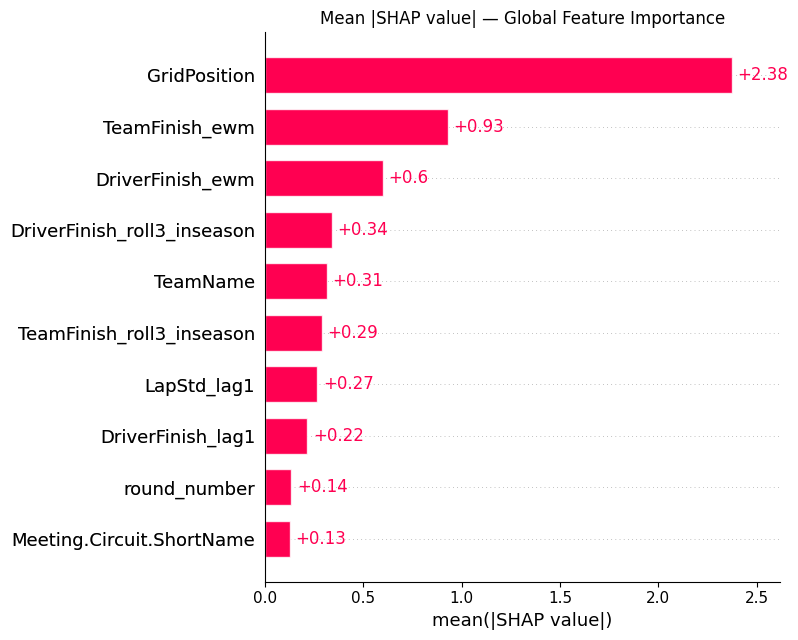

In [4]:
shap.plots.bar(shap_values, show=False)
plt.title("Mean |SHAP value| — Global Feature Importance")
plt.tight_layout()
plt.show()

## 5. Beeswarm Plot

Extends the bar plot with the full distribution: each dot is one test-set race entry, its horizontal position is that row's SHAP value (impact on predicted finishing position), and its colour is the row's own feature value (red = high, blue = low). This shows both magnitude *and* direction — e.g. whether a high `GridPosition` (starting further back) consistently pushes predictions toward a worse (higher-numbered) finishing position, or whether the relationship is more mixed.

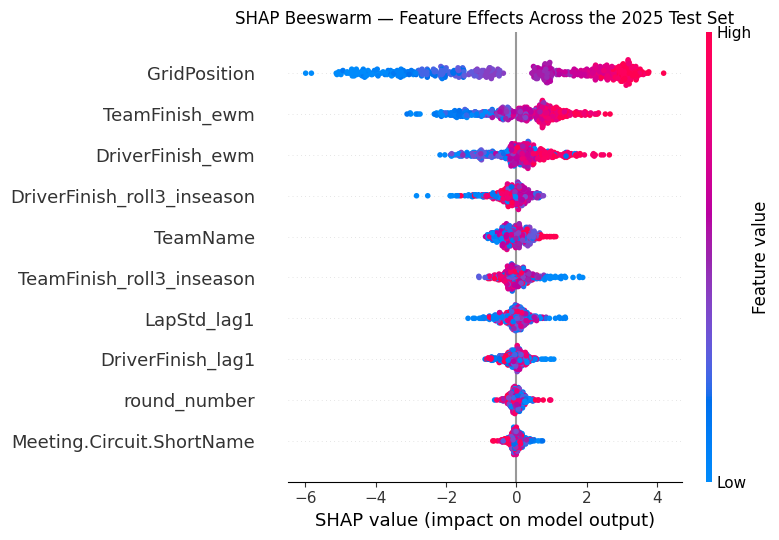

In [5]:
shap.plots.beeswarm(shap_values, show=False)
plt.title("SHAP Beeswarm — Feature Effects Across the 2025 Test Set")
plt.tight_layout()
plt.show()

## 6. Selecting Instances for Local Explanations

Waterfall and force plots explain a single prediction, so we pick two contrasting, informative rows from the test set rather than an arbitrary index:

- **Best prediction** — smallest absolute error, where the model's reasoning should look clean and confident.
- **Worst prediction** — largest absolute error, where the model's reasoning reveals what it got wrong.

In [6]:
abs_error = (test_Y.values - test_preds)
abs_error = np.abs(abs_error)

best_idx = int(np.argmin(abs_error))
worst_idx = int(np.argmax(abs_error))

for label, idx in [("Best", best_idx), ("Worst", worst_idx)]:
    print(f"{label:>5} prediction -> row {idx}: actual={test_Y.values[idx]:.0f}, "
          f"predicted={test_preds[idx]:.2f}, abs_error={abs_error[idx]:.2f}")

 Best prediction -> row 334: actual=4, predicted=4.00, abs_error=0.00
Worst prediction -> row 333: actual=19, predicted=2.64, abs_error=16.36


## 7. Waterfall Plots

Shows how a single prediction is built up: starting from the base value (expected finishing position over the training data), each bar adds or subtracts one feature's contribution, ending at the final predicted position. Features are ordered by contribution magnitude, with the smallest collapsed into an "other features" bucket.

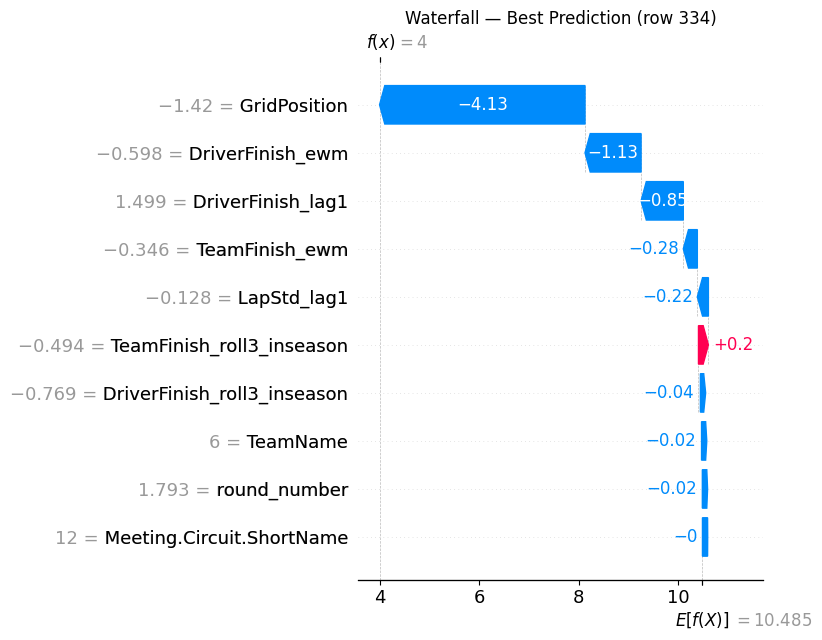

In [7]:
shap.plots.waterfall(shap_values[best_idx], show=False)
plt.title(f"Waterfall — Best Prediction (row {best_idx})")
plt.tight_layout()
plt.show()

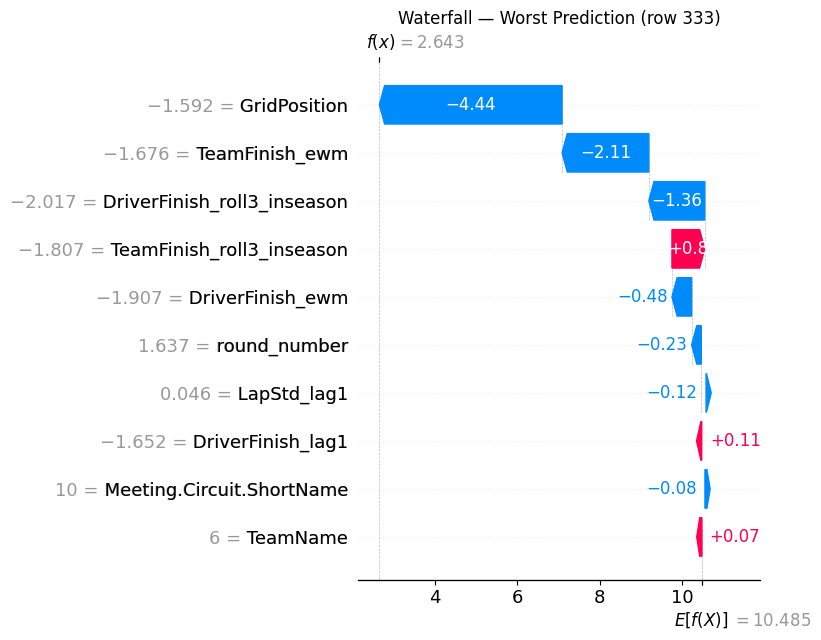

In [8]:
shap.plots.waterfall(shap_values[worst_idx], show=False)
plt.title(f"Waterfall — Worst Prediction (row {worst_idx})")
plt.tight_layout()
plt.show()

## 8. Force Plots

The same additive decomposition as the waterfall plot, laid out as a single horizontal force diagram — features pushing the prediction higher (worse finish) in red on the left, features pushing it lower (better finish) in blue on the right, converging on the final predicted value. Rendered with `matplotlib=True` for a static plot that displays inline and survives notebook export (the default is an interactive JS widget that doesn't render outside a live Jupyter session).

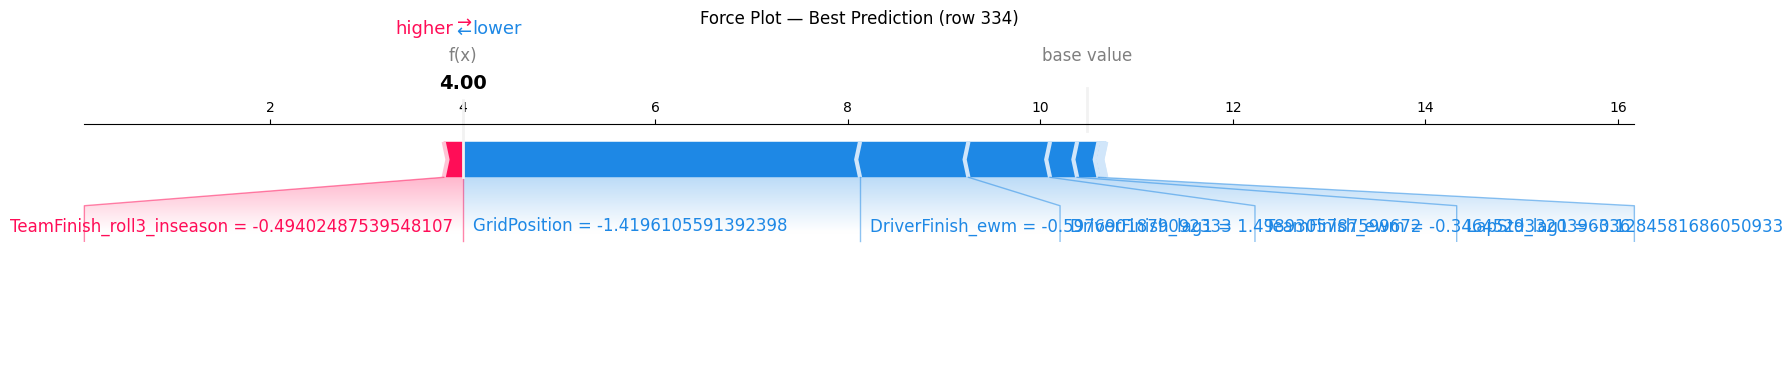

In [9]:
shap.plots.force(shap_values[best_idx], matplotlib=True, show=False)
plt.title(f"Force Plot — Best Prediction (row {best_idx})", y=1.4)
plt.show()

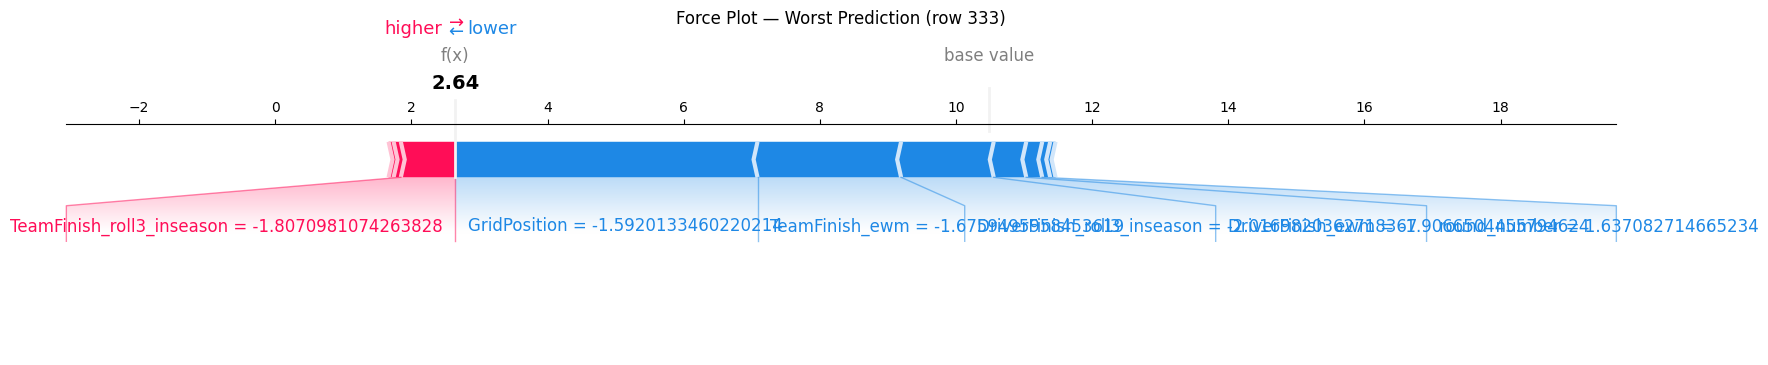

In [10]:
shap.plots.force(shap_values[worst_idx], matplotlib=True, show=False)
plt.title(f"Force Plot — Worst Prediction (row {worst_idx})", y=1.4)
plt.show()

## 9. Dependence Plots — Top 3 Features

For each of the top 3 features by mean |SHAP| (Section 4), plots that feature's value (x-axis, standardised) against its SHAP value (y-axis, impact on predicted position) across every test row. `shap.plots.scatter` auto-selects a second feature to colour by — the one with the strongest interaction — surfacing effects the beeswarm plot's fixed layout can't show, such as whether the effect of one feature depends on the value of another.

Top 3 features: ['GridPosition', 'TeamFinish_ewm', 'DriverFinish_ewm']


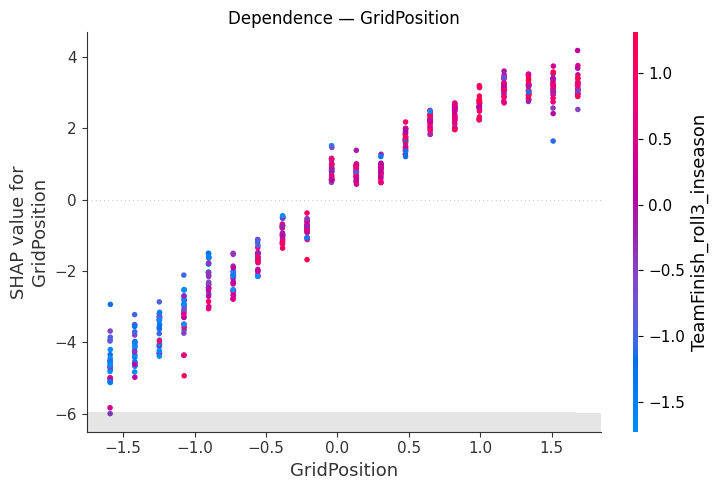

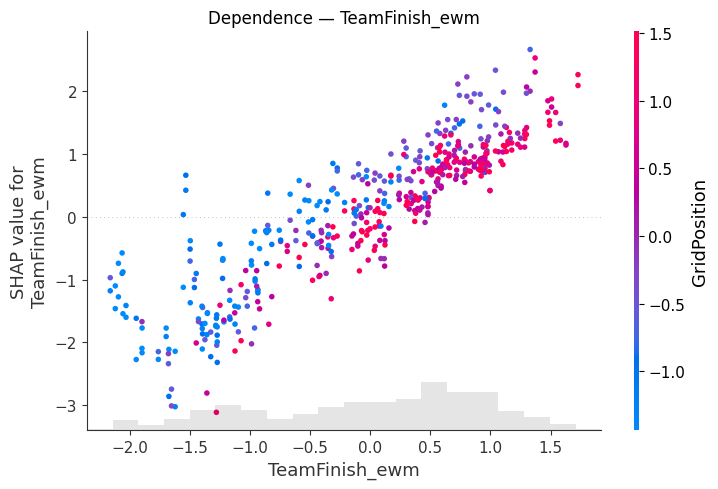

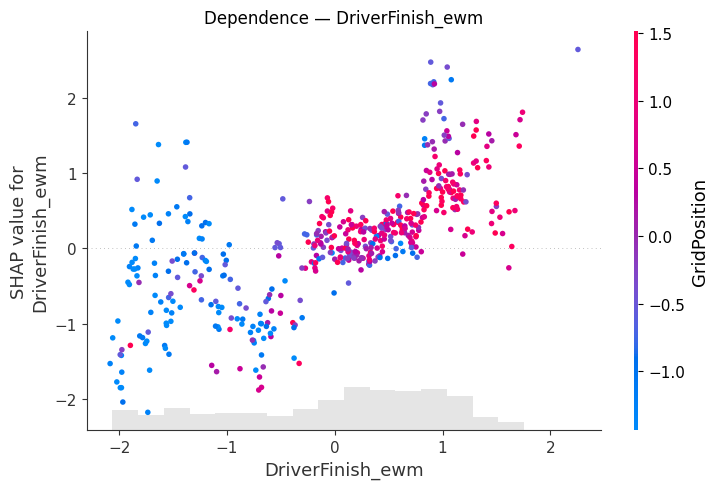

In [11]:
mean_abs_shap = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=FINAL_FEATURES
).sort_values(ascending=False)
top3_features = mean_abs_shap.index[:3].tolist()
print(f"Top 3 features: {top3_features}")

for feature in top3_features:
    shap.plots.scatter(shap_values[:, feature], color=shap_values, show=False)
    plt.title(f"Dependence — {feature}")
    plt.tight_layout()
    plt.show()

## 10. Heatmap Plot

An instance-by-feature view of every SHAP value in the test set at once: rows are the 479 test instances (ordered by hierarchical clustering, so similar explanation patterns sit next to each other), columns are features, and colour is the SHAP value. The line above the heatmap traces each row's total prediction. This complements the beeswarm plot (which shows the marginal distribution per feature) by showing co-occurring patterns across features within the same instance — e.g. rows where `GridPosition` and `DriverFinish_ewm` push in the same direction versus rows where they conflict.

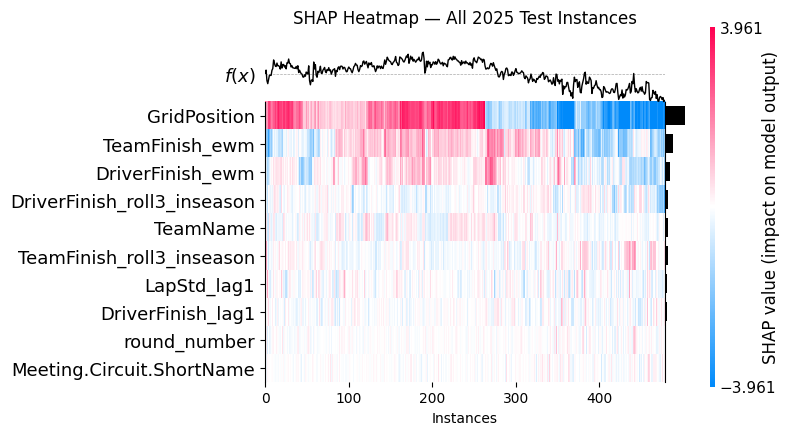

In [12]:
shap.plots.heatmap(shap_values, show=False)
plt.title("SHAP Heatmap — All 2025 Test Instances")
plt.tight_layout()
plt.show()

## 11. Decision Plot — Best vs. Worst Predictions Compared

Traces each selected instance's prediction path from the base value (bottom of the y-axis) through every feature's cumulative contribution up to the final predicted position, with all instances plotted on shared feature-order and x-axis, making it easy to compare *how* two predictions diverge feature-by-feature. Unlike the waterfall plots (Section 7), which show one instance in isolation with its own feature ordering, this plot fixes a common feature order so the best- and worst-prediction lines can be read side by side.

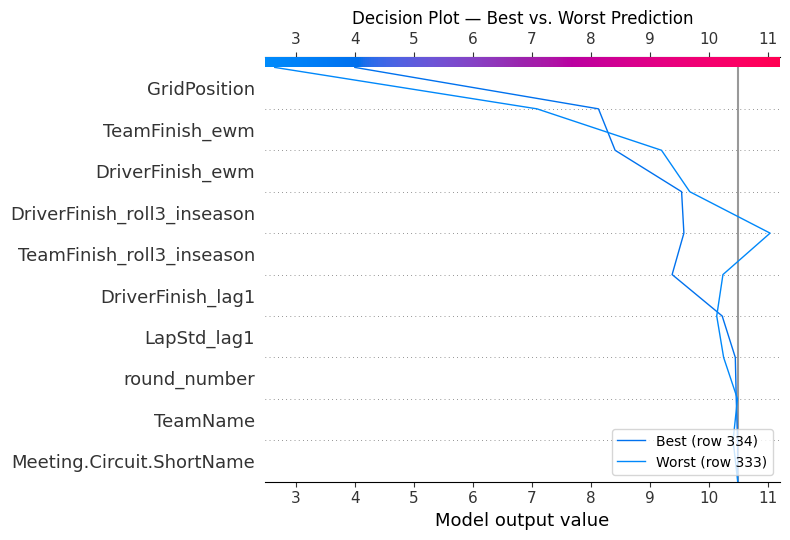

In [13]:
shap.decision_plot(
    shap_values.base_values[0],
    shap_values.values[[best_idx, worst_idx]],
    feature_names=FINAL_FEATURES,
    legend_labels=[f"Best (row {best_idx})", f"Worst (row {worst_idx})"],
    legend_location="lower right",
    show=False,
)
plt.title("Decision Plot — Best vs. Worst Prediction")
plt.tight_layout()
plt.show()

## 12. Takeaways

- **Global ranking mostly agrees with, but refines, the split-count importance from `lightgbm.ipynb`.** The mean |SHAP| bar plot (Section 4) measures actual output impact rather than split frequency, so features that are split on often but with small, offsetting effects rank lower here than in the native LightGBM importance table.
- **The beeswarm plot (Section 5) exposes direction, not just magnitude.** For features like `GridPosition` and the `_ewm`/`_roll3` form indicators, a consistent colour gradient (e.g. red dots on the positive-SHAP side) indicates a monotonic relationship the model has learned reliably; a mixed-colour spread indicates the effect depends heavily on interactions with other features.
- **Best vs. worst predictions (Sections 6–8, 11) show qualitatively different explanation shapes.** The best-prediction waterfall/force plot typically shows a small number of features agreeing on a confident push toward the correct position; the worst-prediction plot often shows large, conflicting contributions — a sign the model was working from misleading or unusually noisy inputs for that driver/race (e.g. a form indicator lagging a sudden change in performance).
- **Dependence plots (Section 9) can reveal non-linearities and interactions the summary statistics hide** — e.g. whether the marginal benefit of a better `GridPosition` flattens out at the extremes (front row vs. mid-pack) rather than scaling linearly, and which second feature most modulates that relationship.
- **The heatmap (Section 10) is the most useful single view for spotting systematic subgroups** — clusters of test rows with similar SHAP patterns often correspond to real-world groupings (e.g. a team's mid-season form spike) that aren't explicit features in the model.
- **Caveat:** all plots explain the model's *learned* behaviour, not ground truth causality — SHAP attributes credit consistently with the model's actual computation, but a feature with high SHAP impact is only as trustworthy as the model itself, which Section 9 of `lightgbm.ipynb` shows still has a meaningful train/test generalisation gap.